   Feature 1  Feature 2  Target
0  -0.872929   0.013042       1
1   1.312935   2.770534       1
2   2.340428   2.420996       1
3   2.294548  -0.404380       1
4   0.944105   0.477241       1


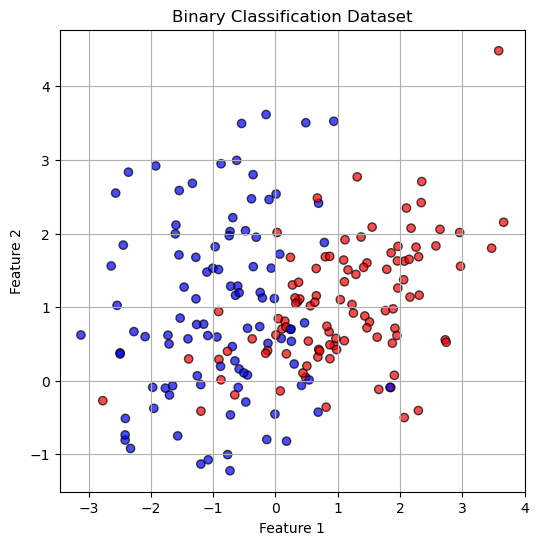

In [4]:
#Dataset
from sklearn.datasets import make_classification
import pandas as pd

# Generate the dataset
X, y = make_classification(
    n_samples=200,        # number of samples
    n_features=2,         # number of features
    n_informative=2,      # number of informative features
    n_redundant=0,        # number of redundant features
    n_clusters_per_class=1,
    random_state=42
)

# Convert to DataFrame
df = pd.DataFrame(X, columns=["Feature 1", "Feature 2"])
df["Target"] = y

# Show the first few rows
print(df.head())

# Optional: visualize
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 6))
plt.scatter(df["Feature 1"], df["Feature 2"], c=df["Target"], cmap="bwr", alpha=0.7, edgecolor='k')
plt.title("Binary Classification Dataset")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.grid(True)
plt.show()

In [6]:
#Step 2: Train-Test Split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

In [12]:
import matplotlib.pyplot as plt
import numpy as np

class LRFinder(tf.keras.callbacks.Callback):
    def __init__(self, min_lr=1e-6, max_lr=1, steps=100):
        super().__init__()
        self.min_lr = min_lr
        self.max_lr = max_lr
        self.total_steps = steps
        self.lrs = []
        self.losses = []
        self.step = 0

    def on_train_batch_end(self, batch, logs=None):
        self.step += 1
        # Exponentially increase LR
        lr = self.min_lr * (self.max_lr / self.min_lr) ** (self.step / self.total_steps)
        self.model.optimizer.learning_rate.assign(lr)

        self.lrs.append(lr)
        self.losses.append(logs["loss"])

        if self.step >= self.total_steps:
            self.model.stop_training = True


In [14]:
# Rebuild or recompile your model
tf.random.set_seed(42)

model = tf.keras.Sequential([
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

# Start with a low LR for LR finder
model.compile(
    loss='binary_crossentropy',
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-6),
    metrics=['accuracy']
)


In [16]:
lr_finder = LRFinder(min_lr=1e-6, max_lr=1, steps=100)

# Run only for 1 epoch, with a small batch size for finer steps
model.fit(
    X_train, y_train,
    batch_size=32,
    epochs=1,
    callbacks=[lr_finder],
    verbose=0
)


In [40]:
#Step 3: Build and Compile Model

import tensorflow as tf

tf.random.set_seed(42)

model = tf.keras.Sequential([
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')  # sigmoid for binary classification
])

model.compile(
    loss='binary_crossentropy',  # binary classification loss
    optimizer=tf.keras.optimizers.Adam(0.00001),
    metrics=['accuracy']
)

In [42]:
#Step 4: Train

import tensorflow as tf

history = model.fit(
    X_train, y_train,
    epochs=200,
    validation_split=0.2,
    verbose=1,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
    ]
)

Epoch 1/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 143ms/step - accuracy: 0.1875 - loss: 0.7185 - val_accuracy: 0.1875 - val_loss: 0.7212
Epoch 2/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - accuracy: 0.1875 - loss: 0.7180 - val_accuracy: 0.1875 - val_loss: 0.7207
Epoch 3/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 0.1875 - loss: 0.7175 - val_accuracy: 0.1875 - val_loss: 0.7201
Epoch 4/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - accuracy: 0.1875 - loss: 0.7171 - val_accuracy: 0.1875 - val_loss: 0.7196
Epoch 5/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - accuracy: 0.1875 - loss: 0.7166 - val_accuracy: 0.1875 - val_loss: 0.7190
Epoch 6/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 0.1906 - loss: 0.7162 - val_accuracy: 0.1875 - val_loss: 0.7185
Epoch 7/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 0.1990 - loss: 0.7158 - val_accuracy: 0.1875 - val_loss: 0.7179
Epoch 8/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - accuracy: 0.1990 - loss: 0.7153 - val_accuracy: 0.2188 - val_loss

In [44]:
#Step 5: Evaluate the model
model.evaluate(X_test, y_test)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.8479 - loss: 0.6393 


[0.6400250196456909, 0.8500000238418579]

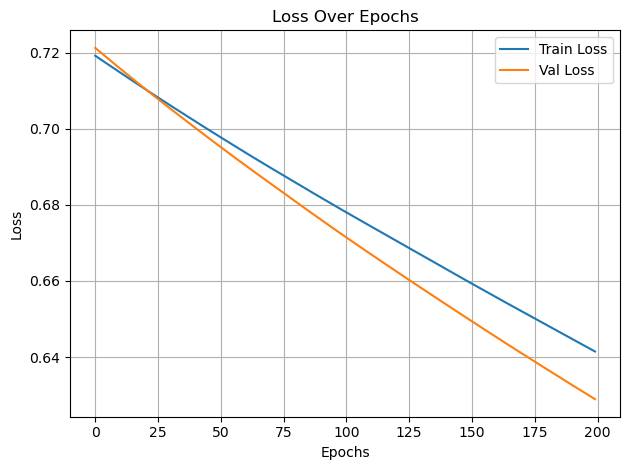

In [46]:
#Step 6: Plot
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title("Loss Over Epochs")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [48]:
#Step 7: Predict
y_preds = model.predict(X_test)
y_preds_binary = (y_preds > 0.5).astype(int)  # threshold for binary output

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step


In [50]:
#Step 8: Evaluate 
from sklearn.metrics import classification_report, confusion_matrix

print(confusion_matrix(y_test, y_preds_binary))
print(classification_report(y_test, y_preds_binary))

[[18  5]
 [ 1 16]]
              precision    recall  f1-score   support

           0       0.95      0.78      0.86        23
           1       0.76      0.94      0.84        17

    accuracy                           0.85        40
   macro avg       0.85      0.86      0.85        40
weighted avg       0.87      0.85      0.85        40



21179/21179 ━━━━━━━━━━━━━━━━━━━━ 35s 2ms/step


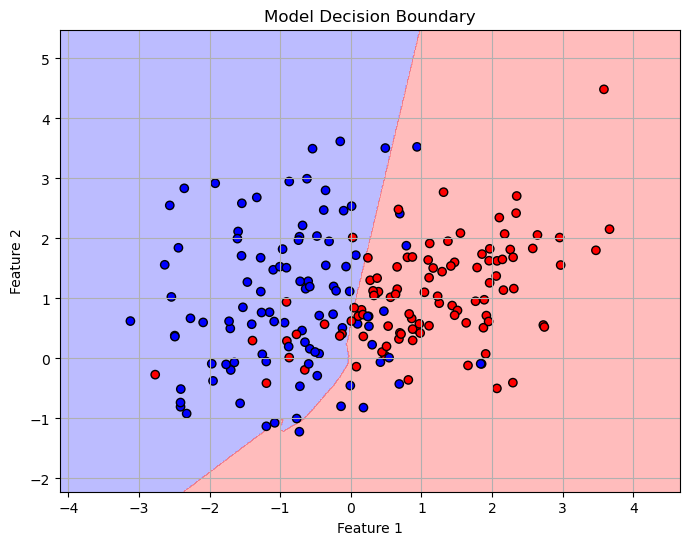

In [52]:
import numpy as np
import matplotlib.pyplot as plt

# Step 1: Create a meshgrid over the feature space
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.01),
                     np.arange(y_min, y_max, 0.01))

# Step 2: Predict for each point in the grid
grid_points = np.c_[xx.ravel(), yy.ravel()]
Z = model.predict(grid_points)
Z = (Z > 0.5).astype(int)  # Convert probabilities to class labels
Z = Z.reshape(xx.shape)

# Step 3: Plot decision boundary
plt.figure(figsize=(8, 6))
plt.contourf(xx, yy, Z, cmap="bwr", alpha=0.3)  # boundary
plt.scatter(X[:, 0], X[:, 1], c=y, cmap="bwr", edgecolors="k")  # data points
plt.title("Model Decision Boundary")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.grid(True)
plt.show()